# 05 — the plates that exist, in the corpus's space

**Summary.** Every plate a run left behind — `final.png` and the FIND/SKETCH thumbnails — embedded
with the same encoder as the corpus and placed against it. Two findings and one refusal:

1. **The finals are not near their position's influences.** `out/condition-withheld/final.png` sits
   at the **46.4th percentile** of all 19,791 corpus works' cosines to the withheld influence
   centroid; `out/openai-withheld/final.png` sits at the **1.5th**. Both at or below chance — which
   is the correct result, because **the artist never saw the influences.** This is the baseline the
   wiring in Stage 5 has to beat.
2. **Percentiles spread what raw cosines hide.** Across the 52 plates the raw cosine to the centroid
   spans 0.29 (0.517..0.808) while the percentile spans 0.91 (0.003..0.915). A raw cosine of 0.74
   reads as "close" and means "the 46th percentile of the corpus", i.e. typical.
3. **Drift during MAKE: NOTHING MEASURED.** There is no plate per MAKE step. A `render` log line
   keeps a `pixelHash`, not the pixels, and sketches are alternatives considered at one moment
   rather than a canvas over time. The sidecar carries that sentence rather than omitting the field.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import kusama as k

dirs = k.trajectory_dirs()
T = {d: k.load_trajectory(d) for d in dirs}
b = k.band()
print(f"{len(dirs)} trajectories with a sidecar:", ", ".join(dirs))

3 trajectories with a sidecar: out/condition-withheld, out/first-withheld, out/openai-withheld


## What each run left behind

In [2]:
for d, t in T.items():
    kinds = pd.Series([p["kind"] for p in t["plates"]]).value_counts().to_dict()
    print(f"{d:<26} position {str(t['positionId']):<12} plates {len(t['plates']):>3}  {kinds}  "
          f"influences {t.get('influencesHash') or 'none'}")
    print(f"{'':<26} steps persisted: {sum(p['step'] is not None for p in t['plates'])} "
          f"-> {'NOTHING MEASURED' if not t['drift']['measured'] else 'measured'} for drift")
print()
print(T[dirs[0]]["drift"]["reason"])

out/condition-withheld     position withheld     plates  17  {'sketch': 16, 'final': 1}  influences 5ccf5677370534ce
                           steps persisted: 0 -> NOTHING MEASURED for drift
out/first-withheld         position withheld     plates  18  {'sketch': 18}  influences 5ccf5677370534ce
                           steps persisted: 0 -> NOTHING MEASURED for drift
out/openai-withheld        position withheld     plates  17  {'sketch': 16, 'final': 1}  influences 5ccf5677370534ce
                           steps persisted: 0 -> NOTHING MEASURED for drift

NOTHING MEASURED: drift needs a plate per MAKE step and no run has ever persisted one. A `render` log line keeps a pixelHash, not the pixels. Sketches are alternatives considered at one moment, not a canvas over time, so a "drift" computed over them would answer a different question while looking like an answer to this one.


## The finals

In [3]:
rows = []
for d, t in T.items():
    for p in t["plates"]:
        if p["kind"] != "final":
            continue
        rows.append(dict(dir=d, novelty=p["novelty"],
                         nearest=p["nearestCorpus"]["id"], near_cos=p["nearestCorpus"]["cosine"],
                         corpus_pct=p["corpusPercentile"],
                         infl_cos=p["cosineToInfluenceCentroid"], infl_pct=p["influencePercentile"],
                         copy=p["copyFlag"]))
fin = pd.DataFrame(rows).set_index("dir")
print(fin.round(4).to_string())
print("\ncorpus_pct: where this plate's nearest-corpus cosine falls in the band of RANDOM corpus pairs.")
print("infl_pct  : where its cosine to the influence centroid falls among all 19,791 corpus works'.")
print("            50% is chance. Below 50% means the plate is LESS like the influences than a")
print("            corpus work picked at random.")

                        novelty    nearest  near_cos  corpus_pct  infl_cos  infl_pct   copy
dir                                                                                        
out/condition-withheld   0.2005  aic-65821    0.7995      0.9668    0.7406    0.4641  False
out/openai-withheld      0.3314  aic-65821    0.6686      0.6105    0.6027    0.0148  False

corpus_pct: where this plate's nearest-corpus cosine falls in the band of RANDOM corpus pairs.
infl_pct  : where its cosine to the influence centroid falls among all 19,791 corpus works'.
            50% is chance. Below 50% means the plate is LESS like the influences than a
            corpus work picked at random.


both finals' nearest corpus work: ['aic-65821']
They share one. Read as a hub effect before reading it as a relationship — notebook 02
shows the top 1% of works absorb 4.7% of all neighbour slots.


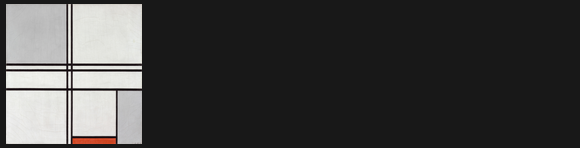

In [4]:
same = fin.nearest.nunique() == 1 and len(fin) > 1
print(f"both finals' nearest corpus work: {fin.nearest.unique()}")
if same:
    print("They share one. Read as a hub effect before reading it as a relationship — notebook 02")
    print("shows the top 1% of works absorb 4.7% of all neighbour slots.")
display(k.thumb_grid(list({p['nearestCorpus']['sha256']
                           for t in T.values() for p in t['plates'] if p['kind'] == 'final'}),
                     cols=4, size=140))

## Every plate: raw cosine versus percentile

52 plates, 52 scored against an influence centroid
raw cosine  span 0.2912  (0.5171..0.8083)
percentile  span 0.9118  (0.0027..0.9145)

copy flags (cosine > 0.95 to a corpus work): 0 of 52


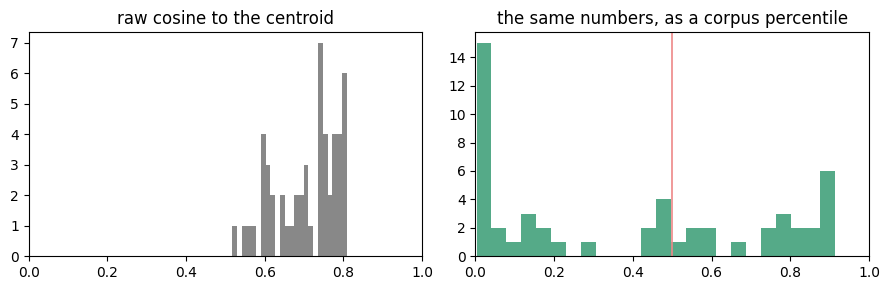

In [5]:
allp = pd.DataFrame([dict(dir=d, **{x: p[x] for x in
                    ("kind", "novelty", "corpusPercentile", "cosineToInfluenceCentroid",
                     "influencePercentile", "copyFlag")})
                     for d, t in T.items() for p in t["plates"]])
scored = allp.dropna(subset=["cosineToInfluenceCentroid"])
print(f"{len(allp)} plates, {len(scored)} scored against an influence centroid")
print(f"raw cosine  span {scored.cosineToInfluenceCentroid.max()-scored.cosineToInfluenceCentroid.min():.4f}"
      f"  ({scored.cosineToInfluenceCentroid.min():.4f}..{scored.cosineToInfluenceCentroid.max():.4f})")
print(f"percentile  span {scored.influencePercentile.max()-scored.influencePercentile.min():.4f}"
      f"  ({scored.influencePercentile.min():.4f}..{scored.influencePercentile.max():.4f})")
print(f"\ncopy flags (cosine > 0.95 to a corpus work): {int(allp.copyFlag.sum())} of {len(allp)}")

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(scored.cosineToInfluenceCentroid, bins=24, color="#888")
ax[0].set_title("raw cosine to the centroid"); ax[0].set_xlim(0, 1)
ax[1].hist(scored.influencePercentile, bins=24, color="#5a8")
ax[1].axvline(0.5, color="#e88", lw=1.2)
ax[1].set_title("the same numbers, as a corpus percentile"); ax[1].set_xlim(0, 1)
fig.tight_layout(); plt.show()

## Novelty, and why it is 1 − cosine and nothing cleverer

`novelty = 1 - cosine to the nearest corpus work`. It is a distance to the closest thing anyone
photographed, not an aesthetic judgement, and it is only readable next to the band: the *closest*
pair of random corpus works sits at 0.969, so a novelty of 0.20 means the plate's nearest neighbour
is closer than a typical pair but nowhere near a duplicate.

In [6]:
print(allp.groupby(["dir", "kind"]).novelty.agg(["count", "min", "median", "max"]).round(4).to_string())
print(f"\nfor reference: novelty of the closest random corpus pair = {1-b['max']:.4f}")
print(f"               novelty of the median random corpus pair  = {1-b['median']:.4f}")

                               count     min  median     max
dir                    kind                                 
out/condition-withheld final       1  0.2005  0.2005  0.2005
                       sketch     16  0.1418  0.1783  0.2102
out/first-withheld     sketch     18  0.1570  0.2594  0.4016
out/openai-withheld    final       1  0.3314  0.3314  0.3314
                       sketch     16  0.1492  0.2925  0.3899

for reference: novelty of the closest random corpus pair = 0.0315
               novelty of the median random corpus pair  = 0.3572


## A caution about percentiles that this project has already been bitten by

A nearest-neighbour percentile is partly a fact about **pool size**. `artist resemblance` searches a
1,500-work stride sample; these sidecars search all 19,791. The same plate scores 83.3 in one and
96.7 in the other. Neither is wrong. Ordering between plates is stable; the level moves 13–14 points
with the pool. Never compare a percentile from one pool to a percentile from another.

## Scratch

In [7]:
# yours